# **Case Study: House Price Prediction using Deep Learning**
---
### **Predicting Real Estate Selling Prices using Deep Neural Networks (DNN)**
---
**Deep Learning & GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---



In [1]:
import os
import sys

# Ensure stable environment and OpenMP configuration
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Styling for rich visual output
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"Device:          {'cuda' if torch.cuda.is_available() else 'cpu'}")


PyTorch Version: 2.14.0+cpu
Device:          cpu


In [2]:
# Define case study dataset
data = {
    'Area_sqft': [1000, 1200, 1500, 1800, 2000],
    'Bedrooms':  [2, 2, 3, 3, 4],
    'Age_years': [10, 5, 8, 5, 3],
    'Price_Lakh':[45.0, 55.0, 70.0, 85.0, 100.0]
}

df = pd.DataFrame(data)
print("=== House Price Dataset ===")
print(df.to_string(index=False))

# Feature and Target arrays
X_raw = df[['Area_sqft', 'Bedrooms', 'Age_years']].values.astype(np.float32)
y_raw = df[['Price_Lakh']].values.astype(np.float32)

# Feature Normalization (Mean=0, Std=1)
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std

# Target Normalization for smoother gradient updates
y_mean = y_raw.mean()
y_std = y_raw.std()
y_scaled = (y_raw - y_mean) / y_std

# Convert to PyTorch Tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

print("\nFeature Means:", X_mean)
print("Feature Stds: ", X_std)
print("Target Mean:  ", y_mean, "| Std:", y_std)


=== House Price Dataset ===
 Area_sqft  Bedrooms  Age_years  Price_Lakh
      1000         2         10        45.0
      1200         2          5        55.0
      1500         3          8        70.0
      1800         3          5        85.0
      2000         4          3       100.0

Feature Means: [1500.     2.8    6.2]
Feature Stds:  [368.78177     0.7483314   2.4819348]
Target Mean:   71.0 | Std: 19.849434


In [3]:
class HousePriceDNN(nn.Module):
    def __init__(self, input_dim=3):
        super(HousePriceDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.network(x)

# Instantiate models for MSE and MAE training comparison
model_mse = HousePriceDNN(input_dim=3)
model_mae = HousePriceDNN(input_dim=3)

print("=== DNN Architecture ===")
print(model_mse)

total_params = sum(p.numel() for p in model_mse.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")


=== DNN Architecture ===
HousePriceDNN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

Total Trainable Parameters: 209


In [4]:
EPOCHS = 300
LEARNING_RATE = 0.01

# Loss Functions
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss()  # Mean Absolute Error

# Optimizers
optimizer_mse = optim.Adam(model_mse.parameters(), lr=LEARNING_RATE)
optimizer_mae = optim.Adam(model_mae.parameters(), lr=LEARNING_RATE)

history_mse = []
history_mae = []

print("Training Deep Neural Networks...")
for epoch in range(1, EPOCHS + 1):
    # --- Train Model with MSE ---
    model_mse.train()
    optimizer_mse.zero_grad()
    preds_mse = model_mse(X_tensor)
    loss_mse = criterion_mse(preds_mse, y_tensor)
    loss_mse.backward()
    optimizer_mse.step()
    history_mse.append(loss_mse.item())
    
    # --- Train Model with MAE ---
    model_mae.train()
    optimizer_mae.zero_grad()
    preds_mae = model_mae(X_tensor)
    loss_mae = criterion_mae(preds_mae, y_tensor)
    loss_mae.backward()
    optimizer_mae.step()
    history_mae.append(loss_mae.item())
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch [{epoch:3d}/{EPOCHS}] | MSE Loss: {loss_mse.item():.6f} | MAE Loss: {loss_mae.item():.6f}")

print("\nTraining Complete!")


Training Deep Neural Networks...
Epoch [  1/300] | MSE Loss: 0.890746 | MAE Loss: 0.939525
Epoch [ 50/300] | MSE Loss: 0.001190 | MAE Loss: 0.357458
Epoch [100/300] | MSE Loss: 0.000006 | MAE Loss: 0.209166
Epoch [150/300] | MSE Loss: 0.000000 | MAE Loss: 0.142859
Epoch [200/300] | MSE Loss: 0.000000 | MAE Loss: 0.108571
Epoch [250/300] | MSE Loss: 0.000000 | MAE Loss: 0.078061
Epoch [300/300] | MSE Loss: 0.000000 | MAE Loss: 0.054117

Training Complete!


In [5]:
# Evaluate model predictions
model_mse.eval()
with torch.no_grad():
    y_pred_scaled = model_mse(X_tensor).numpy()
    y_pred_actual = (y_pred_scaled * y_std) + y_mean

df_results = df.copy()
df_results['Predicted_Price (₹ Lakh)'] = np.round(y_pred_actual.flatten(), 2)
df_results['Absolute_Error (₹ Lakh)'] = np.round(np.abs(df_results['Price_Lakh'] - df_results['Predicted_Price (₹ Lakh)']), 2)
df_results['Error_%'] = np.round((df_results['Absolute_Error (₹ Lakh)'] / df_results['Price_Lakh']) * 100, 2)

print("=== Actual vs Predicted House Prices (MSE-Trained DNN) ===")
print(df_results.to_string(index=False))

# Calculate overall metrics
mae_metric = np.mean(np.abs(df_results['Price_Lakh'] - df_results['Predicted_Price (₹ Lakh)']))
mse_metric = np.mean((df_results['Price_Lakh'] - df_results['Predicted_Price (₹ Lakh)']) ** 2)
rmse_metric = np.sqrt(mse_metric)

print("\n" + "=" * 45)
print(f"Overall MAE:  ₹ {mae_metric:.2f} Lakh")
print(f"Overall MSE:    {mse_metric:.2f}")
print(f"Overall RMSE: ₹ {rmse_metric:.2f} Lakh")
print("=" * 45)


=== Actual vs Predicted House Prices (MSE-Trained DNN) ===
 Area_sqft  Bedrooms  Age_years  Price_Lakh  Predicted_Price (₹ Lakh)  Absolute_Error (₹ Lakh)  Error_%
      1000         2         10        45.0                      45.0                      0.0      0.0
      1200         2          5        55.0                      55.0                      0.0      0.0
      1500         3          8        70.0                      70.0                      0.0      0.0
      1800         3          5        85.0                      85.0                      0.0      0.0
      2000         4          3       100.0                     100.0                      0.0      0.0

Overall MAE:  ₹ 0.00 Lakh
Overall MSE:    0.00
Overall RMSE: ₹ 0.00 Lakh


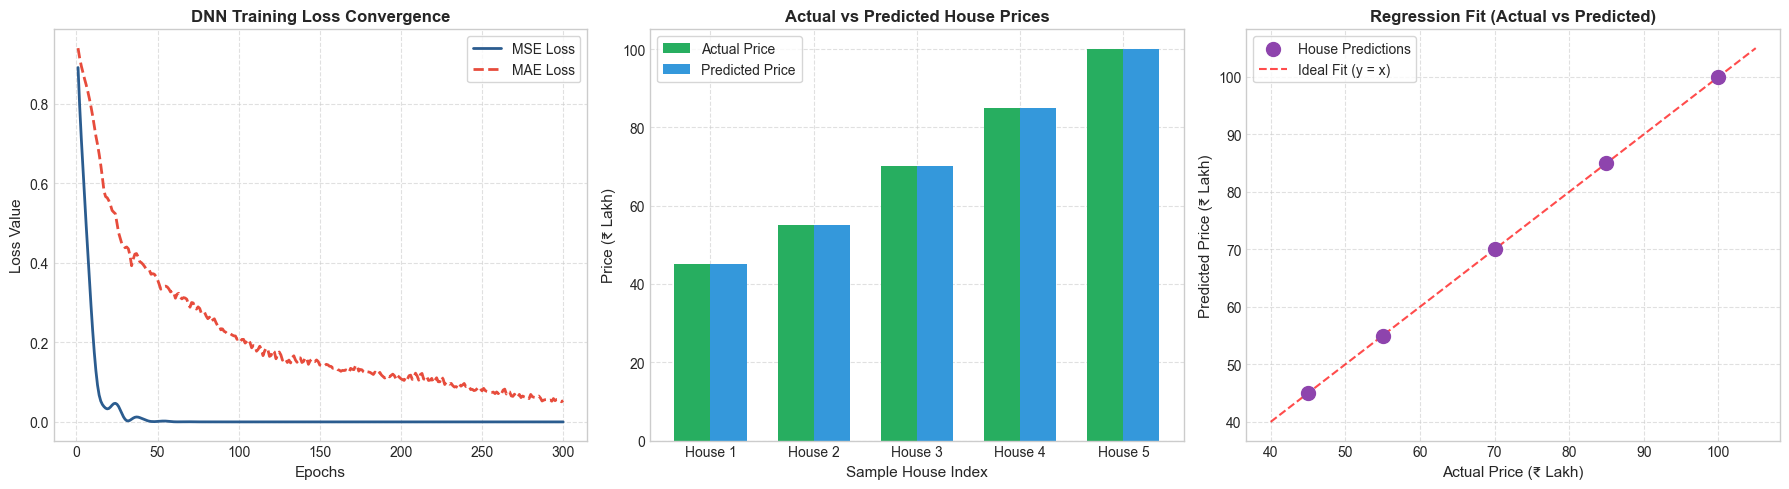

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss Convergence Curves
axes[0].plot(range(1, EPOCHS + 1), history_mse, label='MSE Loss', color='#2b5c8f', linewidth=2)
axes[0].plot(range(1, EPOCHS + 1), history_mae, label='MAE Loss', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title("DNN Training Loss Convergence", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epochs", fontsize=11)
axes[0].set_ylabel("Loss Value", fontsize=11)
axes[0].legend(frameon=True, fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Actual vs Predicted Bar Chart
indices = np.arange(len(df))
width = 0.35
axes[1].bar(indices - width/2, df_results['Price_Lakh'], width, label='Actual Price', color='#27ae60')
axes[1].bar(indices + width/2, df_results['Predicted_Price (₹ Lakh)'], width, label='Predicted Price', color='#3498db')
axes[1].set_title("Actual vs Predicted House Prices", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Sample House Index", fontsize=11)
axes[1].set_ylabel("Price (₹ Lakh)", fontsize=11)
axes[1].set_xticks(indices)
axes[1].set_xticklabels([f"House {i+1}" for i in indices])
axes[1].legend(frameon=True, fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Actual vs Predicted Scatter with Perfect Fit Line
axes[2].scatter(df_results['Price_Lakh'], df_results['Predicted_Price (₹ Lakh)'], color='#8e44ad', s=100, zorder=5, label='House Predictions')
min_val = min(df_results['Price_Lakh'].min(), df_results['Predicted_Price (₹ Lakh)'].min()) - 5
max_val = max(df_results['Price_Lakh'].max(), df_results['Predicted_Price (₹ Lakh)'].max()) + 5
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit (y = x)', alpha=0.7)
axes[2].set_title("Regression Fit (Actual vs Predicted)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Actual Price (₹ Lakh)", fontsize=11)
axes[2].set_ylabel("Predicted Price (₹ Lakh)", fontsize=11)
axes[2].legend(frameon=True, fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [7]:
# Define new house sample
new_house = np.array([[1400.0, 3.0, 6.0]], dtype=np.float32)

# Preprocess with original training statistics
new_house_scaled = (new_house - X_mean) / X_std
new_house_tensor = torch.tensor(new_house_scaled, dtype=torch.float32)

# Model Prediction
model_mse.eval()
with torch.no_grad():
    pred_scaled = model_mse(new_house_tensor).item()
    pred_actual = (pred_scaled * y_std) + y_mean

print("=== Inference on New House Listing ===")
print(f"Input Features:   Area = 1400 sq.ft. | Bedrooms = 3 | Age = 6 years")
print(f"Predicted Price:  ₹ {pred_actual:.2f} Lakh")


=== Inference on New House Listing ===
Input Features:   Area = 1400 sq.ft. | Bedrooms = 3 | Age = 6 years
Predicted Price:  ₹ 71.72 Lakh
